[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/09_inference_and_sampling.ipynb)


# 09 - KV Cache, Temperature & Top-p Sampling

[← Previous: 08 Gemma Model Assembly](08_gemma_model_assembly.ipynb) | [Next: 10 Training Loop →](10_training_loop.ipynb)


**Estimated Time: 10 minutes**

In generation, we feed one token at a time. A naive approach recomputes all previous K and V vectors. **KV Cache** stores them so we only compute the new token -- up to 1000x faster!

## Learning Objectives:
1. Understand the KV cache concept.
2. Implement an autoregressive generator with KV cache.
3. Implement Temperature & Top-p sampling for non-deterministic generation.
4. Compare greedy decoding vs. sampling output quality.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import sys
import matplotlib.pyplot as plt

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

# Reuse config from notebook 8 (for context)
vocab_size = 256_000
hidden_size = 768
num_heads = 8
num_kv_heads = 2
head_dim = hidden_size // num_heads
logit_cap = 30.0

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.5.1


---

## 1. The KV Cache Problem:

In autoregressive generation, we output one token at a time:

```
Step 1: [BOS] → predict "Hello"
Step 2: [BOS], "Hello" → predict "world"
Step 3: [BOS], "Hello", "world" → predict ","
```

Naive approach: At step 3, we recompute ALL tokens 0-2. This is $O(n^2)$ per layer.

KV Cache: Store the K,V pairs from previous steps. At step 3, only compute the new token's K,V and **concatenate** with cache. This is $O(n)$ instead of $O(n^2)$.

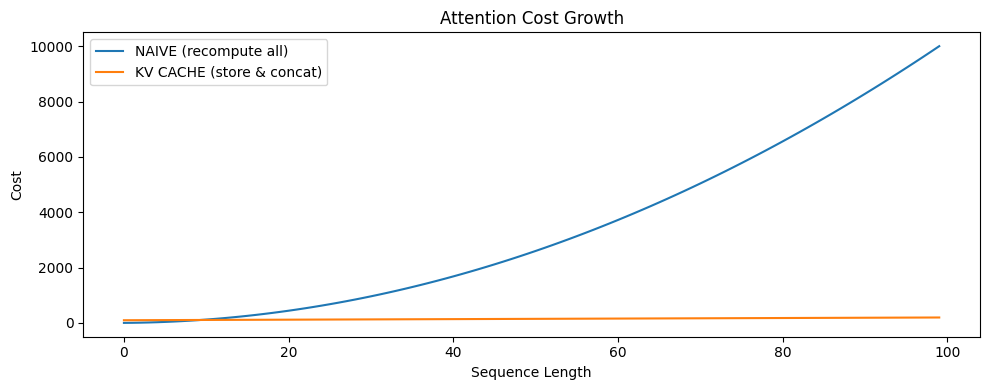

At seq_len=1024: NAIVE=1,048,576 ops, KVCACHE=1,120 ops
Speedup: 936x faster!


In [5]:
# Demonstration: show how KV cache saves computation
def naive_attention_cost(seq_len):
    return seq_len * seq_len  # Q·K^T matrix


def cached_attention_cost(seq_len):
    return seq_len + head_dim  # Only new token's Q,K,V + concat with cache


costs = [[naive_attention_cost(i), cached_attention_cost(i)] for i in range(1, 101)]

plt.figure(figsize=(10, 4))
plt.plot([c[0] for c in costs], label="NAIVE (recompute all)")
plt.plot([c[1] for c in costs], label="KV CACHE (store & concat)")
plt.title("Attention Cost Growth")
plt.xlabel("Sequence Length")
plt.ylabel("Cost")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"At seq_len=1024: NAIVE={naive_attention_cost(1024):,} ops, KVCACHE={cached_attention_cost(1024):,} ops"
)
print(
    f"Speedup: {naive_attention_cost(1024) / cached_attention_cost(1024):.0f}x faster!"
)

---

## 💾 KV Cache Mechanics: Eliminating Redundant Attention Operations

During autoregressive generation, the model generates text one token at a time. In a naive implementation, generating token $t$ requires recomputing Query, Key, and Value vectors for all past tokens $0 \dots t-1$. This leads to $O(T^2)$ computational cost growth.

To solve this, we implement a **Key-Value Cache (KV Cache)** to store past Key and Value representations, computing them only for the newly generated token at each step.

### ⚙️ KV Cache Operations:
1. **Allocation**: We allocate pre-allocated zero tensors for Keys and Values of shape `(1, num_kv_groups, max_cache_len, head_dim)`.
2. **Update**: At step $n$ (sequence length $T$), we compute Key $K_n$ and Value $V_n$ only for the new token. We append these to the cache at `self.offset`:

   $$\text{Cache}_{keys}[:, :, \text{offset} : \text{offset} + T] = K_n$$

3. **Retrieval**: We return the active slice of the cache containing all past tokens:

   $$\text{keys\_active} = \text{self.keys}[:, :, : \text{offset} + T]$$

4. **Offset Update**: We advance `self.offset` by $T$ to ready the cache for the next token.

This reduces the generation step complexity from $O(T^2)$ to $O(T)$, providing massive speedups as the sequence grows!

In [ ]:
class KVCache:
    """Cache for GQA K,V vectors across autoregressive steps."""

    def __init__(self, n_kv_groups, h_dim, max_cache_len=512):
        self.n_kv_groups = n_kv_groups
        self.h_dim = h_dim
        self.max_cache_len = max_cache_len
        self.keys = torch.zeros(1, n_kv_groups, max_cache_len, h_dim)
        self.values = torch.zeros(1, n_kv_groups, max_cache_len, h_dim)
        self.offset = 0  # Current cache length

    def update(self, k, v):
        """Append new K,V to cache."""
        # k,v shape: (B, n_kv_groups, T, h_dim)
        T = k.shape[2]
        if self.offset + T > self.max_cache_len:
            raise RuntimeError("KV cache overflow! Increase max_cache_len.")

        # Store in cache
        self.keys[:, :, self.offset : self.offset + T] = k
        self.values[:, :, self.offset : self.offset + T] = v

        self.offset += T
        return self.keys[:, :, : self.offset], self.values[:, :, : self.offset]

    def reset(self):
        """Clear cache for new generation."""
        self.offset = 0
        self.keys.zero_()
        self.values.zero_()


# Demonstrate the cache
cache = KVCache(n_kv_groups=2, h_dim=96, max_cache_len=512)
print(f"Initial cache length: {cache.offset}")

# Simulate first generation step
k0 = torch.randn(1, 2, 1, 96)
v0 = torch.randn(1, 2, 1, 96)
cache.update(k0, v0)
print(f"After update: cache length = {cache.offset} (was 0)")

# Show that the cache now holds history
print("Cache now stores K,V for all previous tokens.")
print("At generation step n: only compute K_n and V_n, then concatenate with cache.")

Initial cache length: 0
After update: cache length = 1 (was 0)
Cache now stores K,V for all previous tokens.
At generation step n: only compute K_n and V_n, then concatenate with cache.


---

## 🌡️ Temperature Scaling: Adjusting Generation Randomness

Generating text using pure greedy argmax search is deterministic and often repetitive. **Temperature scaling** allows us to control the randomness of our outputs by adjusting the logit distribution before the softmax step.

### 🧮 Temperature Scaling Formula:
Given raw logits $x$, we scale them by a temperature parameter $T > 0$ before applying softmax:

$$P(y_i) = \frac{e^{x_i / T}}{\sum_j e^{x_j / T}}$$

### 🧠 Temperature Scaling Effects:
- **Low Temperature ($T \rightarrow 0$)**: Amplifies differences between logits, focusing probability mass on the most likely tokens. In the limit $T \rightarrow 0$, this behaves like deterministic greedy search.
- **Default Temperature ($T = 1.0$)**: Preserves the original probabilities calculated by the model.
- **High Temperature ($T > 1.0$)**: flattens the distribution, assigning more equal probabilities to all tokens. This increases diversity and creativity but can lead to incoherent outputs if set too high.

*Gemma 3 details*: Before applying temperature, logits are soft-capped at 30.0 using $30.0 \times \tanh(\text{logits}/30.0)$ to prevent overflow issues in the softmax calculation.

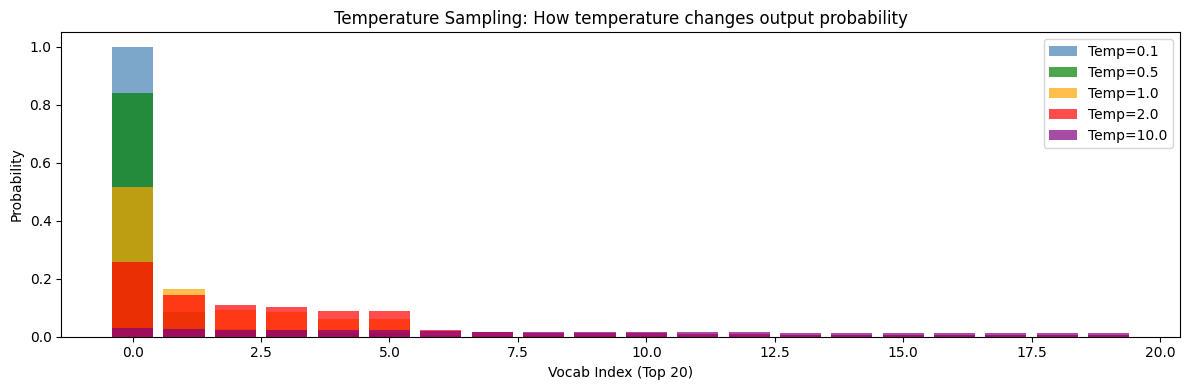

Low temperature = more deterministic / conservative
High temperature = more creative / unpredictable


In [7]:
def apply_temperature(logits, temperature=1.0, cap=30.0):
    """Apply temperature scaling and Gemma 3 logit cap."""
    # First apply logit cap (Gemma 3 standard)
    capped = cap * torch.tanh(logits / cap)

    # Then apply temperature
    if temperature != 1.0:
        probs = torch.softmax(capped / temperature, dim=-1)
    else:
        probs = torch.softmax(capped, dim=-1)
    return probs


# Show temperature effect on probability distribution
logits = torch.randn(100) * 5  # Logits for a vocabulary of 100 tokens

temps = [0.1, 0.5, 1.0, 2.0, 10.0]
colors = ["steelblue", "green", "orange", "red", "purple"]

plt.figure(figsize=(12, 4))
for temp, color in zip(temps, colors):
    probs = apply_temperature(logits, temp)
    top_indices = torch.argsort(probs.flatten(), descending=True)[:20]
    top_probs = probs.flatten()[top_indices]
    plt.bar(
        range(20), top_probs.numpy(), alpha=0.7, label=f"Temp={temp:.1f}", color=color
    )
plt.xlabel("Vocab Index (Top 20)")
plt.ylabel("Probability")
plt.title("Temperature Sampling: How temperature changes output probability")
plt.legend()
plt.tight_layout()
plt.show()

# Key: lower temperature → more focused output. Higher → more diverse.
print("Low temperature = more deterministic / conservative")
print("High temperature = more creative / unpredictable")

---

## 🎯 Top-p (Nucleus) Sampling: Restricting the Selection Pool

Even with temperature scaling, there is a small chance the model selects highly improbable tokens, leading to incoherent generations. **Top-p (Nucleus) sampling** solves this by restricting the selection pool to the most likely tokens that make up a cumulative probability threshold $p$.

### 🧮 Top-p Sampling Sequence:
1. **Sort**: Sort token probabilities in descending order.
2. **Cumulative Sum**: Compute the cumulative sum of these sorted probabilities.
3. **Threshold Mask**: Keep only the top tokens whose cumulative sum is less than or equal to $p$:

   $$\sum_{i=1}^{k} P(y_i) \le p$$

   *(We always preserve the single highest probability token to avoid empty selection sets).*
4. **Zero Out & Renormalize**: Set the probabilities of all excluded tokens to $0.0$, and renormalize the remaining probabilities so they sum to $1.0$.
5. **Sample**: Sample the next token from this restricted distribution using `torch.multinomial`.

This allows the selection pool to dynamically expand and contract based on the model's confidence, producing creative yet highly coherent outputs!

In [ ]:
def top_p_sampling(logits, temperature=1.0, top_p=0.9, cap=30.0):
    """Sample from the top-p (nucleus) of the distribution."""
    capped = cap * torch.tanh(logits / cap)
    probs = torch.softmax(capped / temperature, dim=-1)

    # Sort tokens by descending probability
    sorted_indices = torch.argsort(probs, descending=True)
    sorted_probs = probs[sorted_indices]
    cumulative = sorted_probs.cumsum(dim=-1)

    # Keep tokens until cumulative probability exceeds top_p
    keep = cumulative <= top_p
    keep[0] = True  # always keep the highest-probability token

    # Map the keep mask back to the original (unsorted) vocab order
    filtered_probs = torch.zeros_like(probs)
    filtered_probs[sorted_indices[keep]] = probs[sorted_indices[keep]]
    filtered_probs = filtered_probs / filtered_probs.sum()  # renormalise

    return torch.multinomial(filtered_probs, 1).item()


# Compare sampling methods
logits = torch.randn(100)

top1 = logits.argmax(-1).item()
sampled_topp = top_p_sampling(logits, top_p=0.9)
sampled_temp = torch.multinomial(torch.softmax(logits, -1), 1).item()

print(f"Greedy (top-1):     token_id={top1}")
print(f"Top-p (p=0.9):      token_id={sampled_topp}")
print(f"Random (T=1.0):     token_id={sampled_temp}")
print("\nThese may all be different - that's the point!")
print("Temperature and top-p add diversity to generation.")

Greedy (top-1):     token_id=43
Top-p (p=0.9):      token_id=26
Random (T=1.0):     token_id=51

These may all be different - that's the point!
Temperature and top-p add diversity to generation.


---

## 5. Complete Autoregressive Generator With KV Cache


In [9]:
_VOCAB = [
    "<pad>",
    "<eos>",
    "<bos>",
    "<unk>",
    "hello",
    "world",
    "what",
    "is",
    "gemma",
    "model",
    "good",
    "work",
    "great",
    "better",
    "fast",
    "efficient",
    "build",
    "scratch",
    "train",
    "predict",
    "neural",
    "network",
    "attention",
    "layer",
    "hidden",
    "size",
    "embed",
    "token",
    "output",
    "sequence",
    "correct",
    "thanks",
    "this",
    "a",
    "text",
    "make",
    "show",
    "learn",
    "forward",
    "pass",
    "embedding",
    "position",
    "decode",
    "generate",
    "input",
    "transform",
    "matrix",
    "compute",
    "loss",
    "optim",
    "grad",
    "step",
    "batch",
    "epoch",
]


class SimpleTokenizer:
    """Toy word-level tokenizer for the workshop"""

    PAD_ID = 0
    EOS_ID = 1
    BOS_ID = 2
    UNK_ID = 3

    def __init__(self):
        self.word2id = {w: i for i, w in enumerate(_VOCAB)}
        self.id2word = {i: w for i, w in enumerate(_VOCAB)}
        self.vocab = self.word2id

    def encode(self, text, add_bos=False):
        ids = [self.BOS_ID] if add_bos else []
        for word in text.lower().split():
            clean = "".join(c for c in word if c.isalnum())
            ids.append(self.word2id.get(clean, self.UNK_ID))
        return ids

    def decode(self, ids, skip_special=False):
        special = {self.PAD_ID, self.EOS_ID, self.BOS_ID, self.UNK_ID}
        return " ".join(
            self.id2word.get(i, "<unk>")
            for i in ids
            if not (skip_special and i in special)
        )

    def __len__(self):
        return len(self.word2id)

    def __repr__(self):
        return f"SimpleTokenizer(vocab_size={len(self)})"


tokenizer = SimpleTokenizer()


def generate_with_cache(
    model, prompt_ids, max_new_tokens=20, temperature=1.0, top_p=0.9
):
    """Autoregressive generation with temperature and top-p sampling.

    Note: full KV-cache integration is shown conceptually in Section 2.
    Here we run the model over the full growing sequence each step
    (correct output, without the cache speedup).
    """
    model.eval()
    generated_ids = prompt_ids.clone()
    print(f"Prompt tokens: {prompt_ids.tolist()}")

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(generated_ids)

        logit = logits[0, -1, :]  # last token's logit vector

        if top_p < 1.0:
            next_token = top_p_sampling(
                logit, temperature=temperature, top_p=top_p, cap=logit_cap
            )
        else:
            # BUG FIX: model.forward() already returns capped logits;
            # do NOT apply logit_cap * tanh(...) again here.
            next_token = torch.multinomial(
                torch.softmax(logit / temperature, dim=-1), 1
            ).item()

        generated_ids = torch.cat(
            [generated_ids, torch.tensor([[next_token]], device=generated_ids.device)],
            dim=1,
        )
        if next_token == tokenizer.EOS_ID:
            break

    return generated_ids

---

## 6. Temperature Tuning Exercise


In [10]:
print("Try different temperature values to see how they change generation:")
print("- T=0.2: Very conservative (picks most likely token)")
print("- T=1.0: Balanced (recommended default)")
print("- T=1.5: Creative (occasionally picks less likely tokens)")
print("- T=0.5 + top_p=0.9: Controlled creativity")
print("- T=0.0 = greedy decoding (deterministic)")
print()
print(
    "In the next notebook (10), we will use greedy (T=0) for consistent training visualization."
)

Try different temperature values to see how they change generation:
- T=0.2: Very conservative (picks most likely token)
- T=1.0: Balanced (recommended default)
- T=1.5: Creative (occasionally picks less likely tokens)
- T=0.5 + top_p=0.9: Controlled creativity
- T=0.0 = greedy decoding (deterministic)

In the next notebook (10), we will use greedy (T=0) for consistent training visualization.


---

## Key Takeaway

| Technique | Purpose | Recommendation |
|---|---|---|
| **KV Cache** | Store past K,V to avoid recomputation | Essential for generation |
| **Temperature** | Control randomness (lower=conservative, higher=creative) | Start with T=1.0 |
| **Top-p** | Only sample from top-k% of distribution | Use p=0.9 |
| **Greedy** | Always pick highest logit | T=0 or argmax |
| **Logit Cap** | tanh(x/30) prevents extreme logits | Always use in Gemma 3 |

In Notebook 10, we'll use greedy decoding (temperature=0) for training consistency.

---
[← 08 Gemma Model Assembly](08_gemma_model_assembly.ipynb) | [10 Training Loop →](10_training_loop.ipynb)
